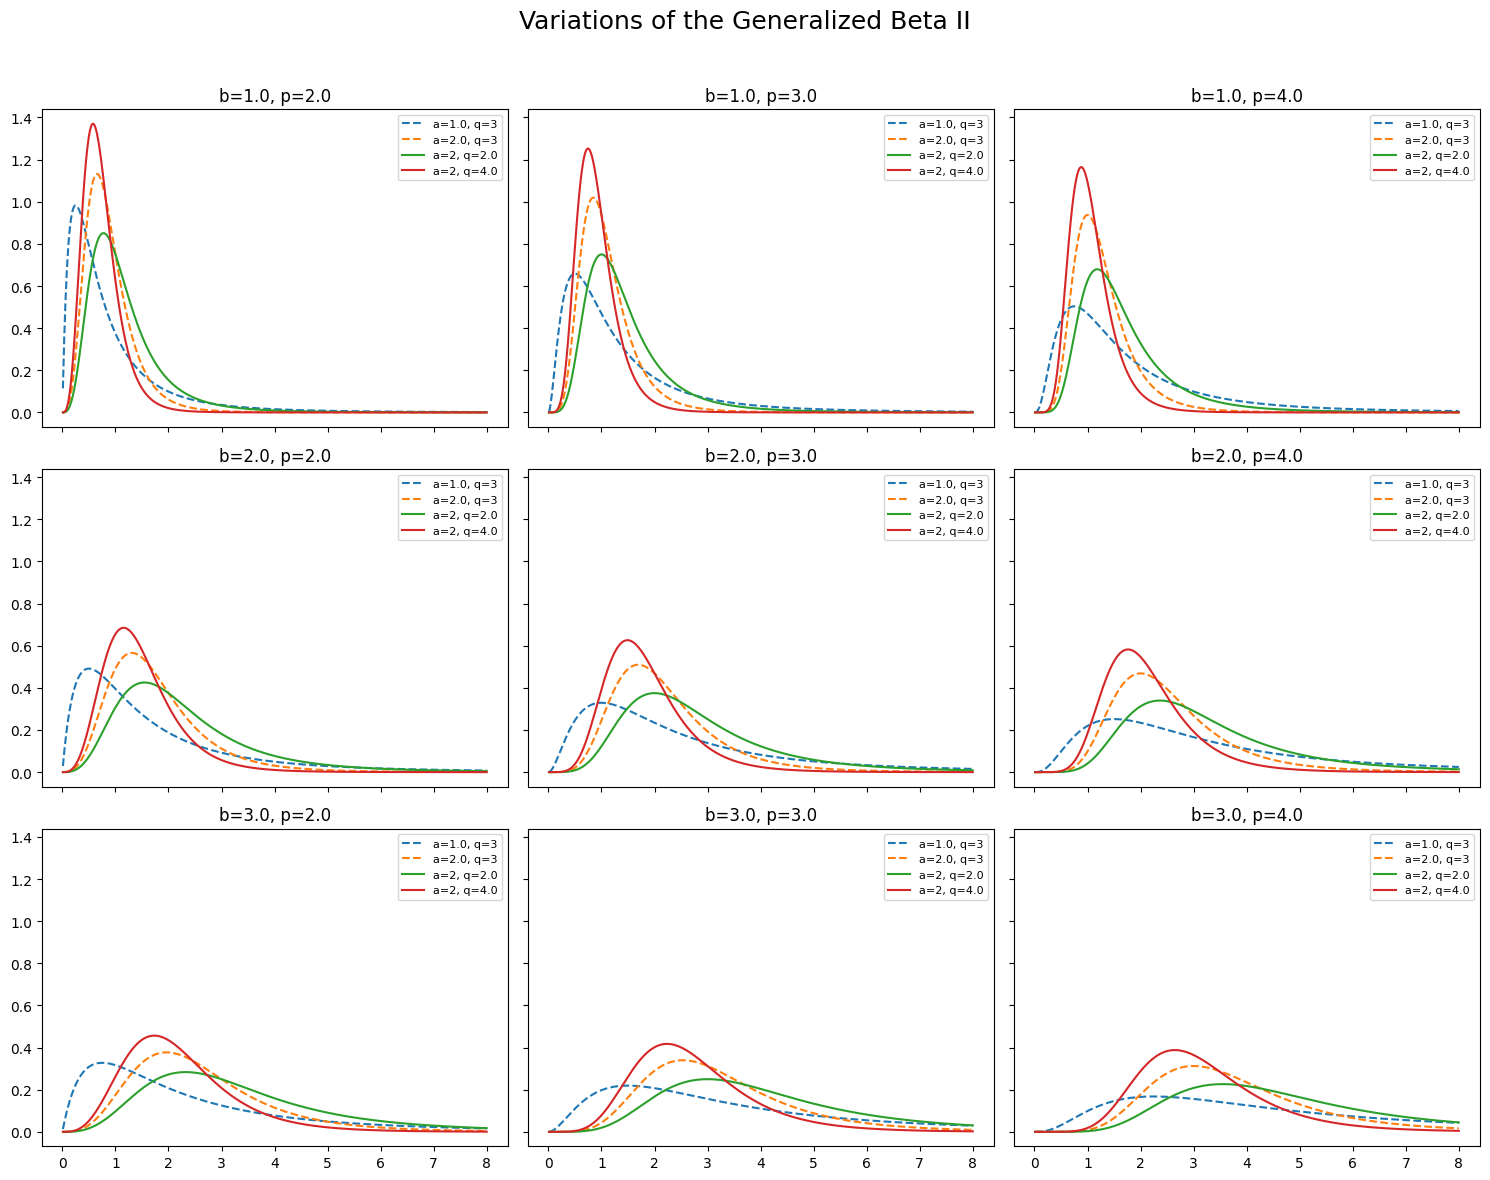

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import beta

# =========================
# GB2 PDF
# =========================
def gb2_pdf(y, a, b, p, q):
    numerator = a * y**(a*p - 1)
    denominator = (b**(a*p)) * beta(p, q) * (1 + (y/b)**a)**(p+q)
    return numerator / denominator


# =========================
# Better parameter choices
# =========================

b_values = [1.0, 2.0, 3.0]        # Rows (scale shifts)
p_values = [2.0, 3.0, 4.0]        # Columns (avoid singularity)

a_values = [1.0, 2.0]             # Dashed
q_values = [2.0, 4.0]             # Solid

# Support
y = np.linspace(0.01, 8, 1000)

# =========================
# Plot mosaic
# =========================

fig, axes = plt.subplots(len(b_values), len(p_values),
                         figsize=(15, 12), sharex=True, sharey=True)

for i, b in enumerate(b_values):
    for j, p in enumerate(p_values):

        ax = axes[i, j]

        # ---- Dashed: varying a ----
        for a in a_values:
            pdf_vals = gb2_pdf(y, a=a, b=b, p=p, q=3.0)  # fixed q
            ax.plot(y, pdf_vals, linestyle='--',
                    label=f'a={a}, q=3')

        # ---- Solid: varying q ----
        for q in q_values:
            pdf_vals = gb2_pdf(y, a=2.0, b=b, p=p, q=q)  # fixed a
            ax.plot(y, pdf_vals, linestyle='-',
                    label=f'a=2, q={q}')

        ax.set_title(f"b={b}, p={p}")
        ax.legend(fontsize=8)

fig.suptitle("Variations of the Generalized Beta II", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()